## **Loading Data and Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

medical = pd.read_csv('/content/Medical_dataset.csv')
medical.head()

,PatientID,Age,Gender,City,MonthlyIncome,BloodPressure,Cholesterol,BMI,Diabetes,HeartDisease,HospitalVisits,TreatmentCost,AI_RiskScore,Churned
0,1001,56.0,Male,Faisalabad,103588.0,143.0,263.0,34.87,No,No,3.0,141016.0,0.86,Yes
1,1002,69.0,NaN,Karachi,167603.0,100.0,256.0,NaN,No,Yes,0.0,53825.0,0.51,No
2,1003,46.0,Female,Islamabad,108340.0,159.0,186.0,34.80,Yes,Yes,4.0,18877.0,0.11,Yes
3,1004,32.0,Male,Lahore,114439.0,155.0,228.0,34.61,No,No,5.0,NaN,0.69,No
4,1005,60.0,Male,Islamabad,195929.0,145.0,241.0,31.49,No,No,8.0,134065.0,0.52,Yes


In [ ]:
medical.dtypes

,0
PatientID,int64
Age,float64
Gender,object
City,object
MonthlyIncome,float64
BloodPressure,float64
Cholesterol,float64
BMI,float64
Diabetes,object
HeartDisease,object


In [ ]:
medical['City'].unique()

array(['Faisalabad', 'Karachi', 'Islamabad', 'Lahore', 'Hyderabad', nan],
      dtype=object)

## **1. Data Cleaning and Processing**

In [ ]:
# a) Identify missing values in the dataset and display their count.
medical.isnull().sum().sort_values(ascending=False)

,0
Age,50
BloodPressure,50
MonthlyIncome,50
TreatmentCost,50
BMI,50
Cholesterol,50
HospitalVisits,50
HeartDisease,30
City,30
Gender,30


In [ ]:
# b) Filling numeric missing values using median and categorical values using
num_cols = medical.select_dtypes(include=["int64", "float64"]).columns
medical[num_cols] = medical[num_cols].fillna(medical[num_cols].median(numeric_only=True))

In [ ]:
# For text values
text_cols = medical.select_dtypes(include="object").columns
medical[text_cols] = medical[text_cols].fillna(medical[text_cols].mode().iloc[0])

In [ ]:
# To check all the values are done
medical.isnull().sum().sort_values(ascending=False)

,0
PatientID,0
Age,0
Gender,0
City,0
MonthlyIncome,0
BloodPressure,0
Cholesterol,0
BMI,0
Diabetes,0
HeartDisease,0


In [ ]:
# c) Removing extra spaces from text columns using string functions.
text_cols = medical.select_dtypes(include="object").columns
text_cols = medical[text_cols].apply(lambda s: s.astype(str).str.strip())

In [ ]:
# d) Converting numeric columns into appropriate datatype.
medical['PatientID'] = medical['PatientID'].astype(str)
medical.dtypes

,0
PatientID,object
Age,float64
Gender,object
City,object
MonthlyIncome,float64
BloodPressure,float64
Cholesterol,float64
BMI,float64
Diabetes,object
HeartDisease,object


## **2. Exploratory Data Analysis**

In [ ]:
# a) Find number of unique values in each column.
medical.nunique().sort_values(ascending=False)

,0
PatientID,1000
MonthlyIncome,950
TreatmentCost,945
BMI,733
Cholesterol,150
AI_RiskScore,101
BloodPressure,100
Age,62
HospitalVisits,12
City,5


In [ ]:
len(medical[(medical['City'] == 'Karachi') & (medical['HeartDisease'] == 'Yes')])

95

In [ ]:
# b) Display top 5 categories with highest average value.
medical.groupby('City')['TreatmentCost'].mean().sort_values(ascending=False).head(5)

,TreatmentCost
City,
Lahore,110959.074627
Faisalabad,101727.010331
Hyderabad,100981.673367
Islamabad,100704.931953
Karachi,97101.322751


In [ ]:
# c) Create groups using bins and show distribution.
bins = [0, 25, 35, 45, 60, 100]
labels = ["<=25","26-35","36-45","46-60","60+"]
medical["AgeGroup"] = pd.cut(medical["Age"], bins=bins, labels=labels)
medical["AgeGroup"].value_counts()

,count
AgeGroup,
60+,319
46-60,272
36-45,162
26-35,131
<=25,116


In [ ]:
# d) Generate correlation matrix for numeric columns.
medical.corr(numeric_only=True)

,Age,MonthlyIncome,BloodPressure,Cholesterol,BMI,HospitalVisits,TreatmentCost,AI_RiskScore
Age,1.000000,0.018364,0.018932,0.001652,0.052809,0.005594,0.022606,-0.001236
MonthlyIncome,0.018364,1.000000,-0.012962,0.008512,0.016856,0.015780,-0.006967,0.054018
BloodPressure,0.018932,-0.012962,1.000000,-0.029967,-0.012244,0.036948,0.034353,-0.022065
Cholesterol,0.001652,0.008512,-0.029967,1.000000,-0.018640,-0.033771,0.043398,0.014465
BMI,0.052809,0.016856,-0.012244,-0.018640,1.000000,-0.010403,-0.009211,-0.015434
HospitalVisits,0.005594,0.015780,0.036948,-0.033771,-0.010403,1.000000,-0.002923,0.027614
TreatmentCost,0.022606,-0.006967,0.034353,0.043398,-0.009211,-0.002923,1.000000,0.008238
AI_RiskScore,-0.001236,0.054018,-0.022065,0.014465,-0.015434,0.027614,0.008238,1.000000


## **3. Data Analysis Using Group**

In [ ]:
#a) Using groupby(), calculate average BMI, treatment cost, and hospital visits for each disease category.
medical.groupby('City')[['BMI', 'TreatmentCost', 'HospitalVisits']].mean()

,BMI,TreatmentCost,HospitalVisits
City,,,
Faisalabad,26.057975,101727.010331,5.690083
Hyderabad,26.081960,100981.673367,5.085427
Islamabad,26.515917,100704.931953,5.763314
Karachi,26.858862,97101.322751,5.793651
Lahore,26.683955,110959.074627,5.666667


In [ ]:
#b) Calculate percentage of heart disease patients using crosstab().
pd.crosstab(medical['City'], medical['HeartDisease'], normalize='index')*100

HeartDisease,No,Yes
City,,
Faisalabad,50.413223,49.586777
Hyderabad,50.251256,49.748744
Islamabad,54.437870,45.562130
Karachi,49.735450,50.264550
Lahore,53.731343,46.268657


# c) Explain how data analysis supports AI-based decision making.

Data analysis is the fuel for AI engines. Data cleaning which includes filling missing values, identifying outliers, and correcting data types turn the noisy data into useful information, which help AI in better decision making.

Good data will also help avoid data bias, which can skew the results of prediction models.

## **4. Basic Data Analysis**

In [ ]:
# a) Display first and last five rows of dataset.
medical.head(5)

,PatientID,Age,Gender,City,MonthlyIncome,BloodPressure,Cholesterol,BMI,Diabetes,HeartDisease,HospitalVisits,TreatmentCost,AI_RiskScore,Churned,AgeGroup
0,1001,56.0,Male,Faisalabad,103588.0,143.0,263.0,34.870,No,No,3.0,141016.0,0.86,Yes,46-60
1,1002,69.0,Male,Karachi,167603.0,100.0,256.0,26.485,No,Yes,0.0,53825.0,0.51,No,60+
2,1003,46.0,Female,Islamabad,108340.0,159.0,186.0,34.800,Yes,Yes,4.0,18877.0,0.11,Yes,46-60
3,1004,32.0,Male,Lahore,114439.0,155.0,228.0,34.610,No,No,5.0,101879.5,0.69,No,26-35
4,1005,60.0,Male,Islamabad,195929.0,145.0,241.0,31.490,No,No,8.0,134065.0,0.52,Yes,46-60


In [ ]:
medical.tail(5)

,PatientID,Age,Gender,City,MonthlyIncome,BloodPressure,Cholesterol,BMI,Diabetes,HeartDisease,HospitalVisits,TreatmentCost,AI_RiskScore,Churned,AgeGroup
995,1996,50.0,Male,Karachi,156917.0,130.0,171.0,30.34,Yes,No,10.0,129225.0,0.36,No,46-60
996,1997,35.0,Female,Faisalabad,187746.0,130.0,217.0,20.06,No,Yes,2.0,144152.0,0.01,Yes,26-35
997,1998,50.0,Female,Islamabad,138325.0,139.0,193.0,23.15,Yes,No,2.0,170029.0,0.63,No,46-60
998,1999,64.0,Male,Faisalabad,39337.0,119.0,183.0,27.05,No,No,10.0,149980.0,0.70,Yes,60+
999,2000,66.0,Female,Karachi,173385.0,115.0,226.0,27.60,No,Yes,6.0,101188.0,0.65,Yes,60+


In [ ]:
# b) Sort records in descending order and show top 5.
medical.sort_values(by='TreatmentCost', ascending=False).head(5)

,PatientID,Age,Gender,City,MonthlyIncome,BloodPressure,Cholesterol,BMI,Diabetes,HeartDisease,HospitalVisits,TreatmentCost,AI_RiskScore,Churned,AgeGroup
126,1127,62.0,Female,Islamabad,58787.0,157.0,252.0,27.620,Yes,No,9.0,199243.0,0.17,Yes,60+
773,1774,37.0,Male,Lahore,170611.0,85.0,281.0,19.320,No,Yes,5.0,199227.0,0.88,No,36-45
364,1365,66.0,Female,Lahore,98258.0,104.0,261.0,19.310,Yes,Yes,1.0,198611.0,0.18,Yes,60+
845,1846,22.0,Male,Lahore,193489.0,130.0,155.0,24.160,Yes,No,0.0,198609.0,0.93,No,<=25
920,1921,37.0,Male,Faisalabad,100388.0,129.0,176.0,26.485,Yes,Yes,6.0,198475.0,0.90,No,36-45


In [ ]:
# c) Filter patients whose Age is greater than 50 and HospitalVisits are more than 5.
medical[(medical['Age'] > 50) & (medical['HospitalVisits'] > 5)]

,PatientID,Age,Gender,City,MonthlyIncome,BloodPressure,Cholesterol,BMI,Diabetes,HeartDisease,HospitalVisits,TreatmentCost,AI_RiskScore,Churned,AgeGroup
4,1005,60.0,Male,Islamabad,195929.0,145.0,241.0,31.49,No,No,8.0,134065.0,0.52,Yes,46-60
6,1007,78.0,Male,Lahore,135053.0,103.0,247.0,27.82,No,Yes,7.0,104612.0,0.42,Yes,60+
15,1016,70.0,Male,Hyderabad,144917.0,87.0,237.0,32.46,No,Yes,6.0,20775.0,0.78,Yes,60+
26,1027,55.0,Male,Karachi,81063.0,94.0,228.0,34.86,Yes,No,6.0,38734.0,0.59,Yes,46-60
28,1029,77.0,Male,Faisalabad,186216.0,92.0,258.0,21.58,No,Yes,10.0,147728.0,0.74,Yes,60+
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
985,1986,73.0,Male,Hyderabad,41826.0,107.0,158.0,27.52,No,No,6.0,74778.0,0.83,Yes,60+
987,1988,67.0,Male,Islamabad,141668.0,130.0,281.0,29.34,No,No,7.0,155188.0,0.76,Yes,60+
988,1989,76.0,Female,Faisalabad,176590.0,116.0,199.0,25.40,Yes,Yes,7.0,193057.0,0.83,Yes,60+
998,1999,64.0,Male,Faisalabad,39337.0,119.0,183.0,27.05,No,No,10.0,149980.0,0.70,Yes,60+


In [ ]:
# d) Calculate average TreatmentCost for each City using groupby()
medical.groupby('City')['TreatmentCost'].mean()

,TreatmentCost
City,
Faisalabad,101727.010331
Hyderabad,100981.673367
Islamabad,100704.931953
Karachi,97101.322751
Lahore,110959.074627


## **5. Data Visualization**

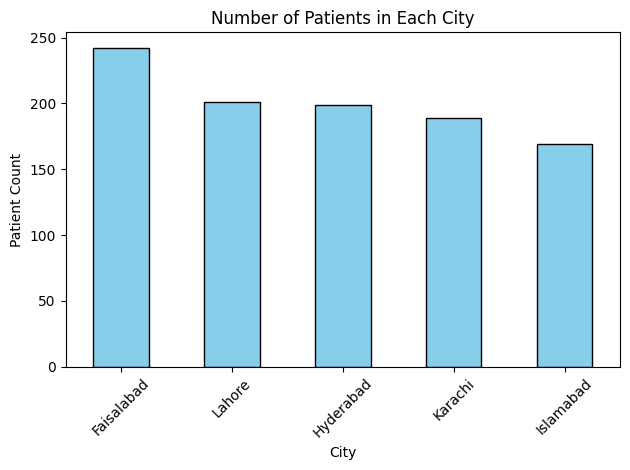

In [ ]:
# a) Create a bar chart showing number of patients in each City
city_counts = medical['City'].value_counts().sort_values(ascending=False)
city_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Number of Patients in Each City')
plt.xlabel('City')
plt.ylabel('Patient Count')
plt.xticks(rotation=45)
plt.tight_layout()

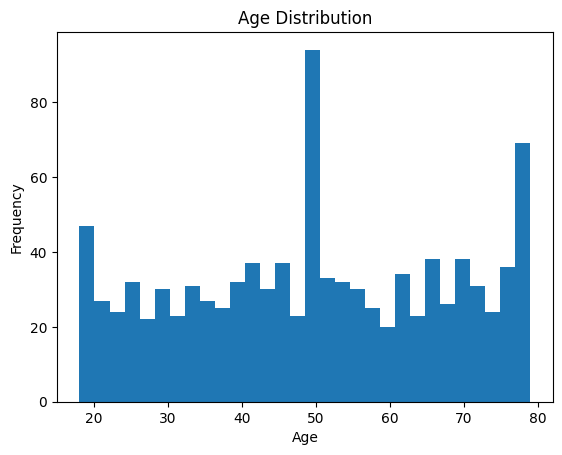

In [ ]:
# b) Plot histogram of Age distribution.
plt.figure()
plt.hist(medical["Age"], bins=30)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")
plt.figtext(0.6)
plt.show()

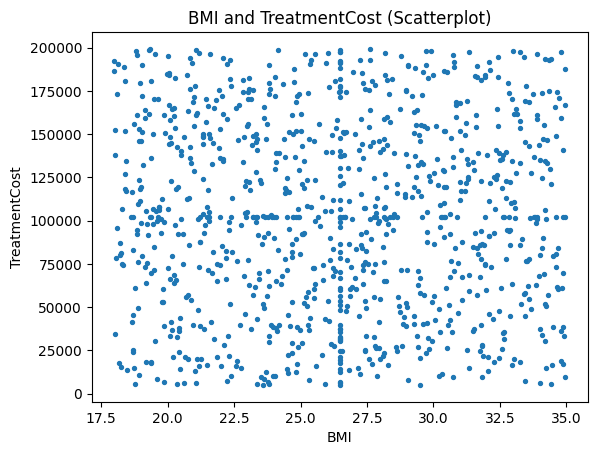

In [ ]:
# c) Create scatter plot between BMI and TreatmentCost.
plt.figure()
plt.scatter(medical["BMI"], medical["TreatmentCost"], s=8)
plt.xlabel("BMI")
plt.ylabel("TreatmentCost")
plt.title("BMI and TreatmentCost (Scatterplot)")
plt.show()

<Axes: >

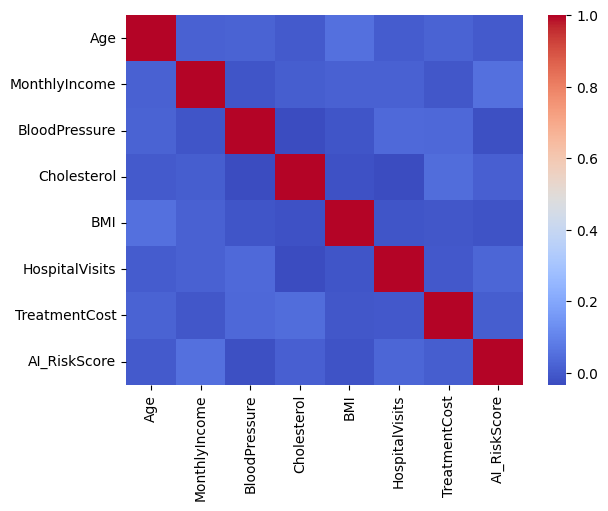

In [ ]:
# d) Plot correlation heatmap for numeric columns.
matrix = medical.corr(numeric_only=True)
sns.heatmap(matrix, cmap='coolwarm')